# Fase 0 — Matemática aplicada, conectada ao código

Notebook enxuto que amarra a **matemática** aos módulos do RodoIA. Três pilares:

1. **Álgebra linear** é o *forward pass* de uma rede.
2. O **gradiente** aponta na direção de maior aumento — por isso descemos contra ele.
3. **Cross-entropy** é a perda *natural* da classificação (log-verossimilhança de Bernoulli).

Referências no repo: `fundamentos/backprop_numpy.py`, `fundamentos/attention.py`, `docs/04`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

## 1. Álgebra linear é o *forward pass*

Uma camada de rede neural é, matematicamente, `z = X·W + b`: uma **multiplicação de matrizes** seguida de um deslocamento. Cada linha de `X` é um exemplo; cada coluna de `W` é um 'detector' que faz um produto interno com o exemplo. É exatamente o `forward` do nosso `MLPNumpy`.

In [2]:
X = np.random.randn(4, 3)  # 4 exemplos, 3 features
W = np.random.randn(3, 2)  # projeta 3 -> 2 neurônios
b = np.zeros(2)
Z = X @ W + b  # o forward de uma camada linear
print("X", X.shape, "@ W", W.shape, "-> Z", Z.shape)
print("cada saída é um produto interno:", np.allclose(Z[0, 0], X[0] @ W[:, 0]))

X (4, 3) @ W (3, 2) -> Z (4, 2)
cada saída é um produto interno: True


## 2. O gradiente aponta na direção de maior aumento

Para uma função `f(θ)`, o gradiente `∇f` é o vetor das derivadas parciais. Fato central: entre todas as direções unitárias `u`, a que **mais aumenta** `f` é `u = ∇f/‖∇f‖`, porque a derivada direcional `∇f·u` é máxima quando `u` aponta na direção de `∇f`.

Por isso o **gradiente descendente** anda no sentido **oposto**: `θ ← θ − lr·∇f`. Abaixo, o campo de gradiente de `f(x,y)=x²+y²`: as setas apontam para fora (maior aumento), perpendiculares às curvas de nível.

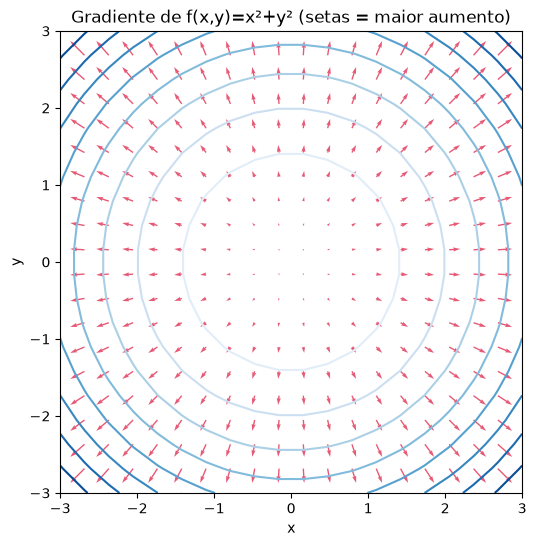

In [3]:
f = lambda x, y: x**2 + y**2
xs = np.linspace(-3, 3, 20)
ys = np.linspace(-3, 3, 20)
Xg, Yg = np.meshgrid(xs, ys)
gx, gy = 2 * Xg, 2 * Yg  # gradiente de x^2+y^2 = (2x, 2y)
fig, ax = plt.subplots(figsize=(6, 6))
cs = ax.contour(Xg, Yg, f(Xg, Yg), levels=10, cmap="Blues")
ax.quiver(Xg, Yg, gx, gy, color="crimson", alpha=0.7)
ax.set(title="Gradiente de f(x,y)=x²+y² (setas = maior aumento)", xlabel="x", ylabel="y")
ax.set_aspect("equal")
plt.show()

A derivada direcional confirma o argumento numericamente: `∇f·u` é máxima quando `u` está alinhado ao gradiente.

In [4]:
grad = np.array([3.0, 4.0])  # um gradiente qualquer
angulos = np.linspace(0, 2 * np.pi, 361)
us = np.c_[np.cos(angulos), np.sin(angulos)]
deriv = us @ grad  # derivada direcional para cada direção
u_otimo = us[np.argmax(deriv)]
print("direção de maior aumento:", u_otimo.round(3))
print("gradiente normalizado    :", (grad / np.linalg.norm(grad)).round(3))
print("coincidem:", np.allclose(u_otimo, grad / np.linalg.norm(grad), atol=1e-2))

direção de maior aumento: [0.602 0.799]
gradiente normalizado    : [0.6 0.8]
coincidem: True


## 3. Por que cross-entropy é a perda natural da classificação

Modelamos `y∈{0,1}` como uma **Bernoulli** com probabilidade `p`. A verossimilhança de um exemplo é `p^y·(1−p)^(1−y)`. Maximizar a verossimilhança do conjunto = **minimizar** a log-verossimilhança negativa média, que é exatamente a **binary cross-entropy**:

$$ \mathrm{BCE} = -\frac{1}{N}\sum_i \big[y_i\log p_i + (1-y_i)\log(1-p_i)\big] $$

Ou seja: usar BCE **não é escolha estética**, é o estimador de máxima verossimilhança. Bônus: combinada com a sigmoid, seu gradiente no logit colapsa para `(p−y)` — o que torna o backward limpo (ver `backprop_numpy.py`).

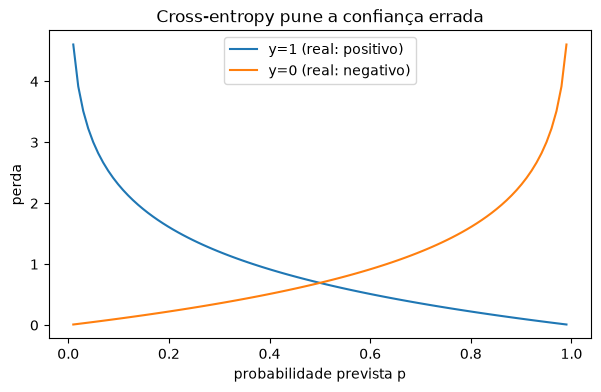

In [5]:
def bce(p, y):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


ps = np.linspace(0.01, 0.99, 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ps, bce(ps, 1), label="y=1 (real: positivo)")
ax.plot(ps, bce(ps, 0), label="y=0 (real: negativo)")
ax.set(
    xlabel="probabilidade prevista p", ylabel="perda", title="Cross-entropy pune a confiança errada"
)
ax.legend()
plt.show()

A perda dispara quando o modelo tem **confiança alta e erra** (p→0 com y=1). Confirmando que BCE = máxima verossimilhança, o `p` que maximiza a verossimilhança de uma amostra é simplesmente a **fração de positivos**:

In [6]:
y = np.random.binomial(1, 0.7, size=5000)
ps = np.linspace(0.01, 0.99, 99)
vero = [np.mean(np.log(np.where(y == 1, p, 1 - p))) for p in ps]  # log-verossimilhança média
p_mle = ps[int(np.argmax(vero))]
print("p que maximiza a verossimilhança:", round(p_mle, 2))
print("fração real de positivos        :", round(y.mean(), 2))

p que maximiza a verossimilhança: 0.71
fração real de positivos        : 0.71


## 4. Juntando tudo: um passo de gradiente descendente

Regressão logística treinada à mão, usando o gradiente `(p−y)` que derivamos. É o mesmo princípio do `passo_treino` do `MLPNumpy` e do laço da MLP em PyTorch.

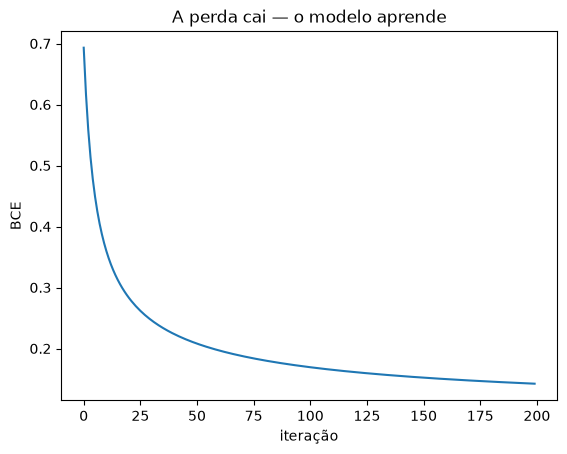

pesos aprendidos: [ 4.44 -2.18  1.09] | verdadeiros: [ 2.  -1.   0.5]


In [7]:
N, d = 2000, 3
Xt = np.random.randn(N, d)
w_verdadeiro = np.array([2.0, -1.0, 0.5])
yt = (Xt @ w_verdadeiro + 0.3 * np.random.randn(N) > 0).astype(float)
sig = lambda z: 1 / (1 + np.exp(-z))
w = np.zeros(d)
lr = 0.5
perdas = []
for _ in range(200):
    p = sig(Xt @ w)
    grad = Xt.T @ (p - yt) / N  # <-- o gradiente (p-y), como no backprop
    w -= lr * grad  # <-- theta <- theta - lr * grad
    perdas.append(bce(p, yt).mean())
plt.plot(perdas)
plt.xlabel("iteração")
plt.ylabel("BCE")
plt.title("A perda cai — o modelo aprende")
plt.show()
print("pesos aprendidos:", w.round(2), "| verdadeiros:", w_verdadeiro)

## Conclusão

- **Forward** = álgebra linear (multiplicação de matrizes).
- **Treino** = descer o gradiente, que aponta para o maior aumento (por isso o sinal negativo).
- **Loss** = cross-entropy porque é máxima verossimilhança para dado binário, e seu gradiente com sigmoid é o limpo `(p−y)`.

Esses três fatos sustentam tudo que fizemos na Fase 0 — do `MLPNumpy` à atenção — e são o material para defender as escolhas numa entrevista técnica.